In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime, timezone

from scipy.stats import norm
from scipy.optimize import brentq

from dataclasses import dataclass

In [2]:
@dataclass
class OptionSlice:
    underlying: str
    spot: float
    maturity_date: datetime.date
    T: float # time to maturity in years
    r: float # risk-free rate
    strikes: np.ndarray
    call_mid: np.ndarray
    put_mid: np.ndarray

In [3]:
def black_scholes_price(S0 : float, K : float, T : float, r : float, sigma : float, option_type : str) -> float:
    """
    Calculate the Black-Scholes price for a given option.
    
    Args:
        S0 (float): Current stock price
        K (float): Strike price
        T (float): Time to maturity in years
        r (float): Risk-free rate
        sigma (float): Volatility of the underlying stock
        option_type (str): "call" or "put"
    Returns:
        float: Price of the option
    """
    if option_type not in ["call", "put"]:
        raise ValueError("Invalid option type. Must be 'call' or 'put'.")
    
    if sigma <= 0 or T <= 0:
        return np.maximum(0.0, S0 - K) if option_type == "call" else np.maximum(0.0, K - S0)
    
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    if option_type == "call":
        return S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * norm.cdf(-d2) - S0 * norm.cdf(-d1)
    

## Get market data ##
Query market data for NVDA and relevant parameters.

In [4]:
ticker = "NVDA"
asset = yf.Ticker(ticker)

# Spot price
S0 = asset.history(period="1d")["Close"].iloc[-1]
print(f"Spot price for {ticker}: {S0:.2f}")

# List of expiries
expiries = asset.options

# Today
today = datetime.now(timezone.utc)

# Risk-free rate
r = yf.Ticker("^TNX").history(period="1d")["Close"].iloc[-1] / 100
print(f"Risk-free rate: {r:.2%}")

Spot price for NVDA: 185.41
Risk-free rate: 4.21%


## Start with 1 expiry ##

In [5]:
expiry_str = expiries[3] # More or less 1 month
expiry_date = datetime.strptime(expiry_str, "%Y-%m-%d").replace(tzinfo=timezone.utc)
T = (expiry_date - today).days / 365
print(f"Analysed expiry: {expiry_str} ({T:.2f} years)")

Analysed expiry: 2026-02-20 (0.03 years)


In [6]:
opt_chain = asset.option_chain(expiry_str)
calls_raw = opt_chain.calls.copy()
puts_raw = opt_chain.puts.copy()
print(f"Gathered {len(calls_raw)} calls and {len(puts_raw)} puts.")

Gathered 68 calls and 59 puts.


In [7]:
def compute_mid_price(row):
    bid = row["bid"]
    ask = row["ask"]
    last = row["lastPrice"]
    
    if bid>0 and ask>0:
        return (bid + ask) / 2
    elif last>0:
        return last
    elif bid>0:
        return bid
    elif ask>0:
        return ask
    else:
        return np.nan

In [8]:
calls_raw["mid"] = calls_raw.apply(compute_mid_price, axis=1)
puts_raw["mid"] = puts_raw.apply(compute_mid_price, axis=1)

Aligning the calls and puts on strike prices.

In [9]:
calls = calls_raw[["strike", "mid"]].rename(columns={"mid": "call_mid"})
puts = puts_raw[["strike", "mid"]].rename(columns={"mid": "put_mid"})

merged = pd.merge(calls, puts, on="strike", how="inner")
display(merged.tail())

,strike,call_mid,put_mid
54,310.0,0.01,128.575
55,320.0,0.01,135.600
56,330.0,0.01,145.650
57,340.0,0.01,158.575
58,420.0,0.01,235.600


Liquidity / Price / nan filters.

In [10]:
# Drop rows with missing prices
merged = merged.dropna(subset=["call_mid", "put_mid"])

# Drop rows with prices below X cents
threshold = 0.00
merged = merged[(merged["call_mid"] > threshold) & (merged["put_mid"] > threshold)]

# Sort by strike and convert to numpy arrays
merged = merged.sort_values(by="strike").reset_index(drop=True)
K = merged["strike"].to_numpy()
C_mid = merged["call_mid"].to_numpy()
P_mid = merged["put_mid"].to_numpy()

display(merged.tail())

,strike,call_mid,put_mid
54,310.0,0.01,128.575
55,320.0,0.01,135.600
56,330.0,0.01,145.650
57,340.0,0.01,158.575
58,420.0,0.01,235.600


Create the slice using the class.

In [11]:
slice1 = OptionSlice(
    underlying=ticker,
    spot=S0,
    maturity_date=expiry_date,
    T=T,
    r=r,
    strikes=K,
    call_mid=C_mid,
    put_mid=P_mid
)


## Compute implied volatility (first using calls). ##

In [12]:
def implied_volatility_call(S0: float, K: float, T: float, r: float, call_price: np.ndarray, sigma_min: float = 1e-6, sigma_max: float = 5.0) -> float:
    """
    Compute the implied volatility for a call option using the Black-Scholes formula and Brent's method.
    """
    # intrinsic value -> floor
    intrinsic = np.maximum(0.0, S0 - K * np.exp(-r * T))
    
    # check if the call is in the money
    if intrinsic + 1e-8 > call_price:
        return np.nan
    
    # objective function
    def f(sigma):
        return black_scholes_price(S0, K, T, r, sigma, "call") - call_price
    
    # find the root of the objective function
    try:
        iv = brentq(f, sigma_min, sigma_max, maxiter=100, xtol=1e-8)
    except ValueError:
        iv = np.nan
    
    return iv
    

In [13]:
iv_calls = np.array([
    implied_volatility_call(slice1.spot, slice1.strikes[i], slice1.T, slice1.r, slice1.call_mid[i])
    for i in range(len(slice1.strikes))
])

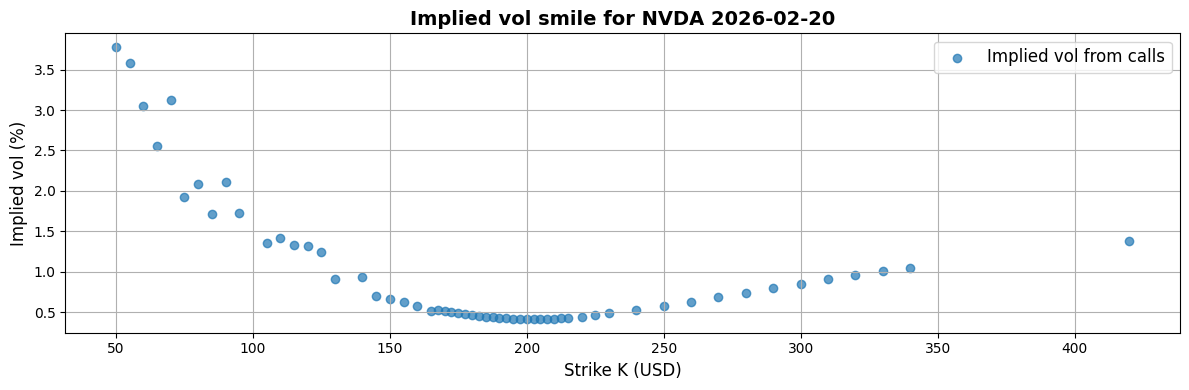

In [14]:
mask = ~np.isnan(iv_calls)
plt.figure(figsize=(12, 4))
plt.scatter(slice1.strikes, iv_calls, label="Implied vol from calls", alpha=0.7)
plt.xlabel("Strike K (USD)", fontsize=12)
plt.ylabel("Implied vol (%)", fontsize=12)
plt.title(f"Implied vol smile for {slice1.underlying} {expiry_str}", fontsize=14, fontweight="bold")
plt.grid(True)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

## Interpolate a Implied Volatility curve ##

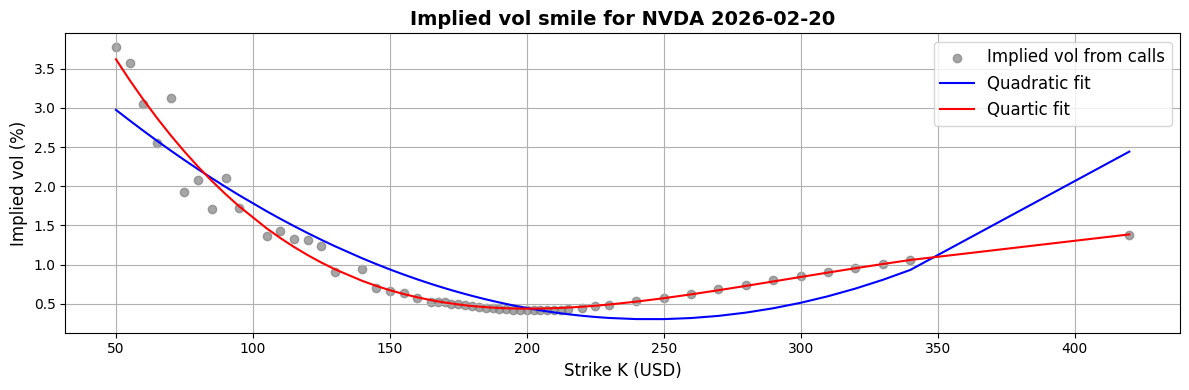

In [15]:
d2_coeffs = np.polyfit(slice1.strikes[mask], iv_calls[mask], 2)
d4_coeffs = np.polyfit(slice1.strikes[mask], iv_calls[mask], 4)
quadratic_fit = np.polyval(d2_coeffs, slice1.strikes[mask])
quartic_fit = np.polyval(d4_coeffs, slice1.strikes[mask])

plt.figure(figsize=(12, 4))
plt.scatter(slice1.strikes, iv_calls, label="Implied vol from calls", alpha=0.7, color="grey")
plt.plot(slice1.strikes[mask], quadratic_fit, label="Quadratic fit", color="blue", linestyle="-")
plt.plot(slice1.strikes[mask], quartic_fit, label="Quartic fit", color="red", linestyle="-")
plt.xlabel("Strike K (USD)", fontsize=12)
plt.ylabel("Implied vol (%)", fontsize=12)
plt.title(f"Implied vol smile for {slice1.underlying} {expiry_str}", fontsize=14, fontweight="bold")
plt.grid(True)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

## ⚠️ Polynomial fits (quadratic / quartic) are not acceptable for volatility surfaces ##
This is exactly where we have to stop and correct the trajectory:
Polynomial fits look smooth, but they violate:
 - convexity in strike
 - no-butterfly arbitrage
 - no-jump/no-negative-density conditions
 - Wings behaviour (Lee's moment formula)
 
Banks never use polynomial fits for implied vol. It is correct as a learning exercise, but now we must switch to the right model: SVI.

In [16]:
# Volatility Surface
from typing import Any

slices = []

for expiry_str in expiries[1:-1]:
    try :
        print(f"Processing {expiry_str}...")
        # Get expiry date in datetime and years
        expiry_date = datetime.strptime(expiry_str, "%Y-%m-%d").replace(tzinfo=timezone.utc)
        T = (expiry_date - today).days / 365
        if T <= 0.0: continue
        
        # Get the option chain
        opt_chain = asset.option_chain(expiry_str)
        calls_raw = opt_chain.calls.copy()
        puts_raw = opt_chain.puts.copy()
        
        # Compute the mid price
        calls_raw["mid"] = calls_raw.apply(compute_mid_price, axis=1)
        puts_raw["mid"] = puts_raw.apply(compute_mid_price, axis=1)
        
        calls = calls_raw[["strike", "mid"]].rename(columns={"mid": "call_mid"})
        puts = puts_raw[["strike", "mid"]].rename(columns={"mid": "put_mid"})

        # Merge the calls and puts
        merged = pd.merge(calls, puts, on="strike", how="inner")
        
        # Drop rows with missing prices
        merged = merged.dropna(subset=["call_mid", "put_mid"])

        # Drop rows with strikes below and above X percents of the spot
        threshold_min = 0.2
        threshold_max = 1 / threshold_min
        merged = merged[(merged["strike"] > threshold_min*S0) & (merged["strike"] < threshold_max*S0)]

        # Sort by strike and convert to numpy arrays
        merged = merged.sort_values(by="strike").reset_index(drop=True)
        K = merged["strike"].to_numpy()
        C_mid = merged["call_mid"].to_numpy()
        P_mid = merged["put_mid"].to_numpy()
        
        # Create the slice for the current expiry
        slice = OptionSlice(underlying=ticker, spot=S0, maturity_date=expiry_date, T=T, r=r, strikes=K, call_mid=C_mid, put_mid=P_mid)
        strikes = slice.strikes
        call_mid = slice.call_mid
        
        # Compute the implied volatility for the calls
        iv_calls = np.array([
        implied_volatility_call(slice.spot, Ki, slice.T, slice.r, Ci)
        for Ki, Ci in zip(strikes, call_mid)
        ])

        mask = ~np.isnan(iv_calls)
        print(f"Found {np.sum(mask)} valid calls for {expiry_str}.")
        slices.append({
            "expiry": expiry_str,
            "T": T,
            "strikes": strikes[mask],
            "iv_calls": iv_calls[mask],
        })
        
    except Exception as e:
        print(f"Error for expiry {expiry_str}: {e}")
        continue
print(f"\nSuccessfully processed {len(expiries)} expiries, for a total of {np.sum([len(s['iv_calls']) for s in slices])} implied volatility points.")

Processing 2026-02-11...
Found 20 valid calls for 2026-02-11.
Processing 2026-02-13...
Found 42 valid calls for 2026-02-13.
Processing 2026-02-20...
Found 57 valid calls for 2026-02-20.
Processing 2026-02-27...
Found 40 valid calls for 2026-02-27.
Processing 2026-03-06...
Found 26 valid calls for 2026-03-06.
Processing 2026-03-13...
Found 19 valid calls for 2026-03-13.
Processing 2026-03-20...
Found 46 valid calls for 2026-03-20.
Processing 2026-04-17...
Found 47 valid calls for 2026-04-17.
Processing 2026-05-15...
Found 51 valid calls for 2026-05-15.
Processing 2026-06-18...
Found 188 valid calls for 2026-06-18.
Processing 2026-07-17...
Found 44 valid calls for 2026-07-17.
Processing 2026-08-21...
Found 50 valid calls for 2026-08-21.
Processing 2026-09-18...
Found 51 valid calls for 2026-09-18.
Processing 2026-11-20...
Found 40 valid calls for 2026-11-20.
Processing 2026-12-18...
Found 188 valid calls for 2026-12-18.
Processing 2027-01-15...
Found 55 valid calls for 2027-01-15.
Proces

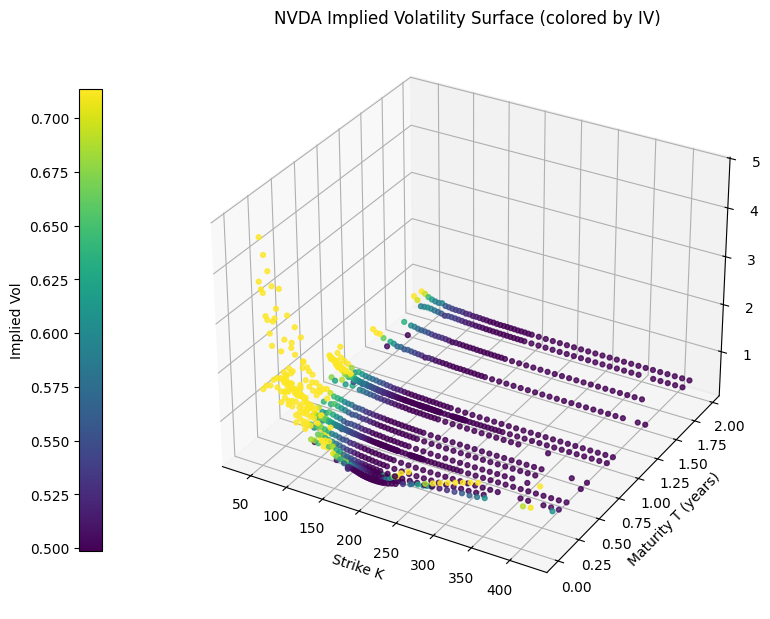

In [20]:
import numpy as np
import matplotlib.cm as cm

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

# normalize IV into [0,1] → color map domain
normalizer = plt.Normalize(slices[0]["iv_calls"].min(), slices[0]["iv_calls"].max())

for slice_data in slices:
    T = slice_data["T"]
    K = slice_data["strikes"]
    iv = slice_data["iv_calls"]
    
    T_vals = np.full_like(K, T)

    colors = cm.viridis(normalizer(iv))     # you can replace viridis with plasma, inferno, coolwarm...

    ax.scatter(K, T_vals, iv, c=colors, s=12, alpha=0.8)

ax.set_xlabel("Strike K")
ax.set_ylabel("Maturity T (years)")
ax.set_zlabel("Implied Vol")
ax.set_title(f"{ticker} Implied Volatility Surface (colored by IV)")

mappable = cm.ScalarMappable(norm=normalizer, cmap=cm.viridis)
mappable.set_array(iv)
fig.colorbar(mappable, ax=ax, shrink=0.6, label="Implied Vol", location="left")

plt.tight_layout()
plt.show()

